# Human Activity Recognition with LSTMs

### Import Libraries

This section imports all necessary libraries for data manipulation, visualization, model building, and evaluation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers,models,callbacks,metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GroupKFold
from sklearn.metrics import roc_auc_score,auc

import gc


This cell imports all the necessary Python libraries for data manipulation (pandas, numpy), visualization (matplotlib, seaborn), and building/training a deep learning model using TensorFlow/Keras. It also includes scikit-learn for data splitting and evaluation metrics.

### Dataset Download

This cell downloads the Human Activity Recognition Using Smartphones Dataset from Kagglehub.

In [ ]:
import kagglehub
path = kagglehub.dataset_download('uciml/human-activity-recognition-with-smartphones')


100%|██████████| 24.5M/24.5M [00:00<00:00, 90.4MB/s]

Extracting files...


This code block uses the `kagglehub` library to download the 'Human Activity Recognition Using Smartphones' dataset. The `path` variable stores the local directory where the dataset files are extracted.

load Train and Test data

In [ ]:
import os

train_path = os.path.join(path, "train.csv")
test_path = os.path.join(path, "test.csv")

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print("Train Data Shape:", df_train.shape)
print("Test Data Shape:", df_test.shape)

Train Data Shape: (7352, 563)
Test Data Shape: (2947, 563)


Here, the downloaded `train.csv` and `test.csv` files are loaded into pandas DataFrames, `df_train` and `df_test`, respectively. The shapes of the loaded DataFrames are then printed to show the number of rows and columns.

In [ ]:
df_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


This displays the first 5 rows of the training DataFrame (`df_train`), giving a quick overview of the data structure and content.

In [ ]:
df_train.tail()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
7347,0.299665,-0.057193,-0.181233,-0.195387,0.039905,0.077078,-0.282301,0.043616,0.060410,0.210795,...,-0.880324,-0.190437,0.829718,0.206972,-0.425619,-0.791883,0.238604,0.049819,30,WALKING_UPSTAIRS
7348,0.273853,-0.007749,-0.147468,-0.235309,0.004816,0.059280,-0.322552,-0.029456,0.080585,0.117440,...,-0.680744,0.064907,0.875679,-0.879033,0.400219,-0.771840,0.252676,0.050053,30,WALKING_UPSTAIRS
7349,0.273387,-0.017011,-0.045022,-0.218218,-0.103822,0.274533,-0.304515,-0.098913,0.332584,0.043999,...,-0.304029,0.052806,-0.266724,0.864404,0.701169,-0.779133,0.249145,0.040811,30,WALKING_UPSTAIRS
7350,0.289654,-0.018843,-0.158281,-0.219139,-0.111412,0.268893,-0.310487,-0.068200,0.319473,0.101702,...,-0.344314,-0.101360,0.700740,0.936674,-0.589479,-0.785181,0.246432,0.025339,30,WALKING_UPSTAIRS
7351,0.351503,-0.012423,-0.203867,-0.269270,-0.087212,0.177404,-0.377404,-0.038678,0.229430,0.269013,...,-0.740738,-0.280088,-0.007739,-0.056088,-0.616956,-0.783267,0.246809,0.036695,30,WALKING_UPSTAIRS


This displays the last 5 rows of the training DataFrame (`df_train`), which can be useful for checking the end of the dataset.

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 31.6+ MB


The `info()` method provides a concise summary of the `df_train` DataFrame, including the column names, their data types, the number of non-null values, and memory usage. This helps in understanding the data types and identifying missing values.

In [ ]:
df_test.head(1)

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.705974,0.006462,0.16292,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2,STANDING


This displays the first row of the test DataFrame (`df_test`) for a quick inspection.

check null values in training data

In [ ]:
print(df_train.isna().sum())
print(df_train.isna().sum().sum())

tBodyAcc-mean()-X       0
tBodyAcc-mean()-Y       0
tBodyAcc-mean()-Z       0
tBodyAcc-std()-X        0
tBodyAcc-std()-Y        0
                       ..
angle(X,gravityMean)    0
angle(Y,gravityMean)    0
angle(Z,gravityMean)    0
subject                 0
Activity                0
Length: 563, dtype: int64
0


This code checks for any missing (null) values in the `df_train` DataFrame. It prints the count of null values for each column and then the total number of null values across the entire DataFrame. In this case, it shows there are no missing values.

counts null values in 'Activity' feature.


In [ ]:
print(df_train["Activity"].value_counts(), "\n")
print(df_test["Activity"].value_counts())

Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64 

Activity
LAYING                537
STANDING              532
WALKING               496
SITTING               491
WALKING_UPSTAIRS      471
WALKING_DOWNSTAIRS    420
Name: count, dtype: int64


This cell counts and displays the occurrences of each unique activity in the 'Activity' column for both the training and test datasets. This helps to understand the distribution of activity classes.

first me check tha unique values and than  map tha value['Activity'] between 1 to 5 number

In [ ]:
activites = df_train["Activity"].unique()

class_map = {i : val for i, val in enumerate(activites)}
class_map_reverse = {key : val for val, key in class_map.items()}

print(class_map)

{0: 'STANDING', 1: 'SITTING', 2: 'LAYING', 3: 'WALKING', 4: 'WALKING_DOWNSTAIRS', 5: 'WALKING_UPSTAIRS'}


This section creates a mapping between the string activity labels (e.g., 'STANDING') and numerical indices (e.g., 0, 1, 2...). This is essential for training machine learning models, which typically require numerical input for classification targets. `class_map` stores the numerical-to-string mapping, and `class_map_reverse` stores the string-to-numerical mapping.

This code converts the encoded numbers (like 0, 1, 2) in the "Activity" column of both the training and testing datasets back into their original text labels (like Walking, Running).

In [ ]:
df_train["Activity"] = df_train["Activity"].apply(lambda x : class_map_reverse[x])
df_test["Activity"] = df_test["Activity"].apply(lambda x : class_map_reverse[x])

This cell applies the reverse mapping created in the previous step to convert the 'Activity' column in both the training and test DataFrames from string labels to their corresponding numerical representations. This is a crucial step for preparing the target variable for a classification model.

This code permanently deletes (drops) the column named "subject" from both your training (df_train) and testing (df_test) DataFrames.

In [ ]:
df_train.drop("subject", axis = 1, inplace = True)
df_test.drop("subject", axis = 1, inplace = True)

The 'subject' column is dropped from both the training and test DataFrames because it typically represents the individual performing the activity and is not a feature used for activity classification. `inplace=True` modifies the DataFrames directly.

This code prepares your data for sequence-based Deep Learning models (like LSTM, RNN, or GRU) by converting tabular data into 3D time-series sequences.

In [ ]:
time_steps = 10

def create_sequences(X, y, time_steps = 5):
    X_, y_ = [], []
    n = X.shape[0]
    for i in np.arange(n - time_steps):
        X_.append(X[i:(i + time_steps)])
        y_.append(y[i + time_steps])
    return np.array(X_), np.array(y_)

X_train_ = df_train.drop("Activity", axis = 1).values
X_test_ = df_test.drop("Activity", axis = 1).values
y_train_ = df_train["Activity"].values
y_test_ = df_test["Activity"].values

X_train, y_train = create_sequences(X_train_, y_train_, time_steps)
X_test, y_test = create_sequences(X_test_, y_test_, time_steps)

print(X_train.shape, X_test.shape)

(7342, 10, 561) (2937, 10, 561)


This custom function `create_sequences` transforms the tabular data into sequences of a specified `time_steps` length. This is a common preprocessing step for time-series and sequential data, especially when using Recurrent Neural Networks (like LSTMs). It creates sequences of `time_steps` observations as input features (X) and the activity at `time_steps` as the target (y). The shapes of the resulting 3D sequences for training and testing are then printed.

This code defines, compiles, and prints the summary of a Deep Learning Stacked LSTM Architecture using TensorFlow/Keras. It is designed to handle sequence or time-series classification (e.g., predicting an activity based on a 10-step history).

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape = X_train.shape[1:]),
    tf.keras.layers.LSTM(units = 256, return_sequences = True),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.LSTM(units = 128, return_sequences = True),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.LSTM(units = 64),
    tf.keras.layers.Dense(units = 32, activation = "relu"),
    tf.keras.layers.Dense(units = len(class_map), activation = "softmax")
])

model.compile(optimizer = tf.keras.optimizers.Adam(0.005), loss = tf.keras.losses.SparseCategoricalCrossentropy(), metrics = ["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 256)        │       837,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,086,438 (4.14 MB)

 Trainable params: 1,086,438 (4.14 MB)

 Non-trainable params: 0 (0.00 B)

This defines a Stacked LSTM (Long Short-Term Memory) neural network model using TensorFlow's Keras API. It consists of multiple LSTM layers followed by Dropout layers for regularization, a Dense layer, and an output Dense layer with a 'softmax' activation for multi-class classification. The model is then compiled with the Adam optimizer, Sparse Categorical Crossentropy loss function, and 'accuracy' as a metric. Finally, `model.summary()` displays the architecture of the model, including the number of layers, output shapes, and parameters.

In [ ]:
cb = tf.keras.callbacks.EarlyStopping(patience = 10, restore_best_weights = True)
history = model.fit(X_train, y_train, epochs = 10, validation_split = 0.3, callbacks = cb)

Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 23s 104ms/step - accuracy: 0.4213 - loss: 1.1276 - val_accuracy: 0.4925 - val_loss: 1.0111
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 16s 100ms/step - accuracy: 0.6414 - loss: 0.7632 - val_accuracy: 0.7767 - val_loss: 0.5812
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 18s 111ms/step - accuracy: 0.7924 - loss: 0.4869 - val_accuracy: 0.7830 - val_loss: 0.5406
Epoch 4/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 19s 102ms/step - accuracy: 0.8081 - loss: 0.4312 - val_accuracy: 0.7744 - val_loss: 0.5577
Epoch 5/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - accuracy: 0.8128 - loss: 0.4194 - val_accuracy: 0.8053 - val_loss: 0.4460
Epoch 6/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 20s 104ms/step - accuracy: 0.8056 - loss: 0.4234 - val_accuracy: 0.7680 - val_loss: 0.4656
Epoch 7/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 17s 107ms/step - accuracy: 0.8159 - loss: 0.4117 - val_accuracy: 0.7531 - val_loss: 0.5942
Epoch 8/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.8194 - loss: 0

This cell sets up and initiates the training process for the LSTM model. An `EarlyStopping` callback is configured to monitor the validation loss and stop training if it doesn't improve for 10 consecutive epochs, restoring the best weights. The model is then trained on the `X_train` and `y_train` data for 10 epochs, with 30% of the training data used for validation.

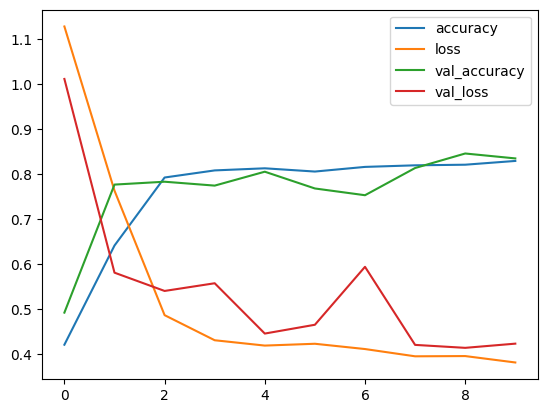

In [ ]:
history_df = pd.DataFrame(history.history)
history_df.plot()
plt.show()

This code block visualizes the training history, plotting the accuracy, loss, validation accuracy, and validation loss over the epochs. This helps in understanding the model's learning progress and identifying overfitting or underfitting.

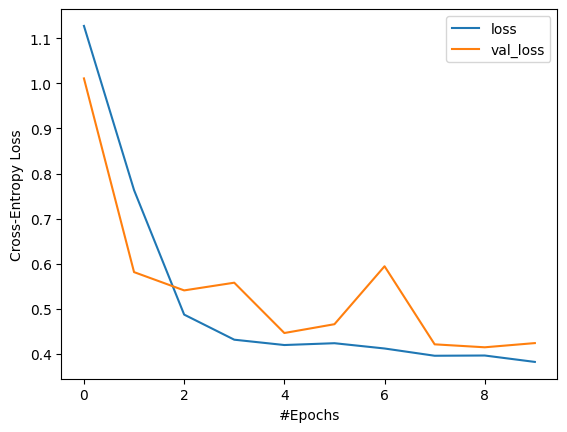

In [ ]:
history_df[["loss", "val_loss"]].plot()
plt.xlabel("#Epochs")
plt.ylabel("Cross-Entropy Loss")
plt.show()


This specifically plots the training loss and validation loss over the epochs, providing a clearer view of how the model's error changes during training on both the training and unseen validation data.

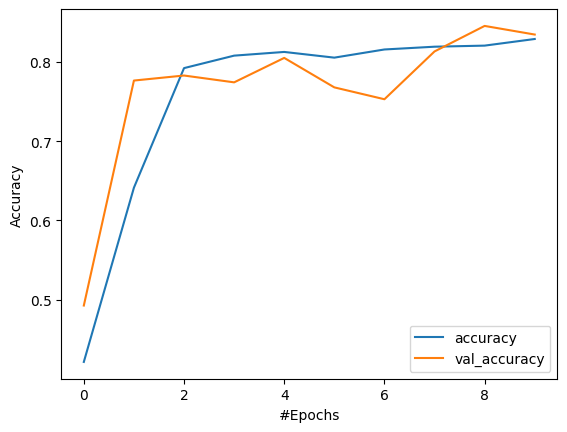

In [ ]:
history_df[["accuracy", "val_accuracy"]].plot()
plt.xlabel("#Epochs")
plt.ylabel("Accuracy")
plt.show()

This plots the training accuracy and validation accuracy over the epochs, illustrating how well the model is performing on both the training and validation sets as training progresses.

In [ ]:
model.evaluate(X_test, y_test)

92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8298 - loss: 0.4028


[0.4028017818927765, 0.8297582864761353]

After training, this cell evaluates the trained model on the unseen test data (`X_test`, `y_test`) to assess its generalization performance. It outputs the test loss and test accuracy.

In [ ]:
y_test_pred_probs = model.predict(X_test)
y_test_pred = np.array([np.argmax(probs) for probs in y_test_pred_probs])

92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step


This code generates activity predictions for the test dataset. `model.predict(X_test)` returns probability distributions for each class, and `np.argmax` is used to convert these probabilities into the single predicted class label for each sample.

In [ ]:
from sklearn.metrics import classification_report

clf_report = classification_report(y_test, y_test_pred, digits = 4)
print(clf_report)

              precision    recall  f1-score   support

           0     0.5806    0.9387    0.7174       522
           1     0.9162    0.3116    0.4650       491
           2     0.9647    0.9665    0.9656       537
           3     0.9587    0.9355    0.9469       496
           4     0.8990    0.8690    0.8838       420
           5     0.8956    0.9469    0.9205       471

    accuracy                         0.8298      2937
   macro avg     0.8691    0.8280    0.8166      2937
weighted avg     0.8668    0.8298    0.8157      2937



This cell generates and prints a detailed classification report, which includes precision, recall, F1-score, and support for each activity class, as well as overall accuracy, macro average, and weighted average. This provides a comprehensive evaluation of the model's performance for each class.

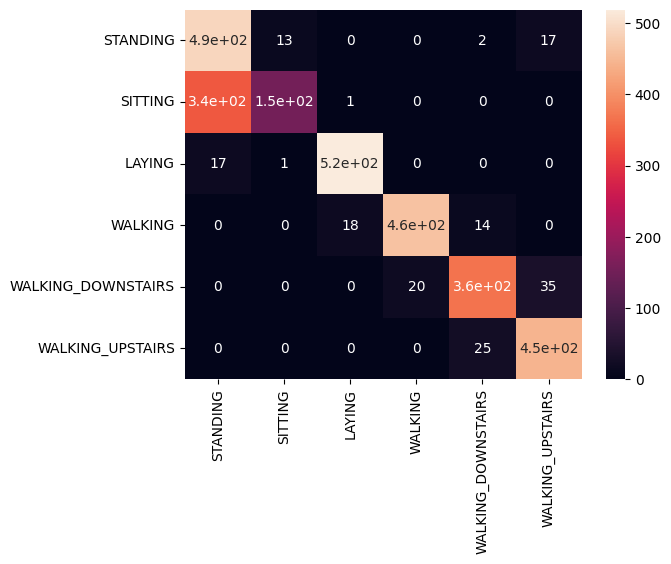

In [ ]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_test_pred)

sns.heatmap(conf_matrix, annot = True, xticklabels = class_map.values(), yticklabels = class_map.values())
plt.show()

A confusion matrix is computed and visualized as a heatmap. The confusion matrix shows the number of correct and incorrect predictions made by the classification model compared to the actual outcomes. It helps in understanding where the model is performing well and where it is making errors (e.g., confusing one activity for another).

In [ ]:
import numpy as np

def predict_from_user_input(model, X_test, class_map):

    try:
        user_input = input(f"Enter a test sample index (0 to {len(X_test) - 1}): ")
        idx = int(user_input)

        if idx < 0 or idx >= len(X_test):
            print(f" Invalid Index! Please enter a number between 0 and {len(X_test) - 1}.")
            return

        sample_sequence = X_test[idx]

        input_data = np.expand_dims(sample_sequence, axis=0)

        pred_probs = model.predict(input_data, verbose=0)
        predicted_index = np.argmax(pred_probs)
        predicted_label = class_map[predicted_index]

        print("-" * 40)
        print(f" Selected Sample Index: {idx}")
        print(f" Predicted Activity  : {predicted_label}")
        print("-" * 40)

    except ValueError:
        print(" Invalid Input! Please enter a valid integer number.")

predict_from_user_input(model, X_test, class_map)

Enter a test sample index (0 to 2936): 3
----------------------------------------
 Selected Sample Index: 3
 Predicted Activity  : STANDING
----------------------------------------


This helper function allows interactive testing of the trained model. Users can input an index for a test sample, and the function will predict the activity for that specific sample using the trained LSTM model. It then prints the selected sample index and its predicted activity.

In [ ]:
from google.colab import files

In [ ]:
model.save('my_har_model.h5')
print("Model saved as my_har_model.h5")

Model saved as my_har_model.h5


This saves the trained Keras model to a file named 'my_har_model.h5'. This allows you to reuse the model later without having to retrain it.

In [ ]:
files.download('my_har_model.h5')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

This code downloads the saved 'my_har_model.h5' file from the Colab environment to your local machine, making it accessible for deployment or further use outside of Colab.

In [ ]:
np.save("X_test.npy", X_test)
np.save("class_map.npy", class_map)
model.save("model.h5")

This cell saves additional components: the preprocessed test input data (`X_test.npy`), the activity class mapping (`class_map.npy`), and the model again as 'model.h5'. These are useful for reproducing results or deploying the model with its necessary context.

In [ ]:
files.download("X_test.npy")
files.download("class_map.npy")
files.download("model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

This downloads the saved NumPy arrays (`X_test.npy`, `class_map.npy`) and the Keras model (`model.h5`) to your local machine.